# YOLO11 Structured Pruning for Pedestrian Detection

In [2]:
import os
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'
os.environ['TORCH_USE_CUDA_DSA'] = '1'

## 1. Installation

In [3]:
# ── Patch: remove corrupted Ultralytics .ttf files that crash matplotlib ──
import shutil, pathlib
from ultralytics.utils import USER_CONFIG_DIR
import matplotlib.font_manager as fm

bad = []
for ttf in pathlib.Path(USER_CONFIG_DIR).glob('*.ttf'):
    try:
        fm.fontManager.addfont(str(ttf))
    except RuntimeError:
        bad.append(ttf)
        ttf.unlink()   # delete the corrupted file
        print(f'Removed corrupted font: {ttf.name}')

if not bad:
    print('All fonts OK — no corrupted files found.')


All fonts OK — no corrupted files found.


In [4]:
# Install required packages
!pip install torch-pruning ultralytics torchinfo matplotlib seaborn --quiet

# Verify torch-pruning version (>=1.3 required for YOLO11 support)
import torch_pruning as tp
print(f"torch-pruning: {tp.__version__}")

torch-pruning: 1.6.0


## 2. Imports & Configuration

In [5]:
import torch
import torch.nn as nn
import torch_pruning as tp
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from copy import deepcopy
from ultralytics import YOLO
from torchinfo import summary
import warnings
warnings.filterwarnings('ignore')

# ── Configuration ────────────────────────────────────────────────────────────
CONFIG = {
    # Paths
    'model_path':     'YOLO11best_to_best__a0.5_t3.0_bs32_e50_scales1.0-1.0-1.0.pt',  # your KD model
    'data_yaml':      'pedestrian.yaml',           # dataset config
    'save_dir':       Path('pruning_outputs'),

    # Pruning
    'pruning_ratio':          0.20,   # fraction of channels to remove per round
    'iterative_rounds':       3,      # number of prune→finetune rounds
    'importance_method':      'l1',   # 'l1' | 'taylor' | 'bn_gamma'
    'bn_sparsity_lambda':     1e-4,   # L1 coefficient for BN γ pre-training
    'bn_sparsity_epochs':     10,     # epochs for BN γ sparsity pre-training
    'bn_gamma_threshold':     0.01,   # prune channels with γ below this value

    # Fine-tuning (after each prune round)
    'finetune_epochs':        50,
    'finetune_lr':            1e-4,
    'finetune_warmup_epochs': 3,
    'imgsz':                  640,

    # Hardware
    'device': 'cuda' if torch.cuda.is_available() else 'cpu',
}

CONFIG['save_dir'].mkdir(exist_ok=True)

print(f"Device     : {CONFIG['device']}")
print(f"Model      : {CONFIG['model_path']}")
print(f"Criterion  : {CONFIG['importance_method']}")
print(f"Rounds     : {CONFIG['iterative_rounds']} × {CONFIG['pruning_ratio']*100:.0f}% channel removal")

Device     : cuda
Model      : YOLO11best_to_best__a0.5_t3.0_bs32_e50_scales1.0-1.0-1.0.pt
Criterion  : l1
Rounds     : 3 × 20% channel removal


## 3. Load Model & Baseline Evaluation

In [6]:
def count_params_macs(model, imgsz=640, device='cpu'):
    """Count params (M) and estimate MACs (G)."""
    params = sum(p.numel() for p in model.parameters()) / 1e6
    # Estimate MACs via torchinfo instead of tp.utils (more stable with YOLO11)
    from torchinfo import summary as ti_summary
    try:
        s = ti_summary(model, input_size=(1, 3, imgsz, imgsz),
                       device=device, verbose=0)
        macs = s.total_mult_adds / 1e9
    except Exception:
        macs = 0.0   # fallback if torchinfo also fails
    return params, macs


# Load KD model
yolo = YOLO(CONFIG['model_path'])
model = yolo.model.to(CONFIG['device'])
model.eval()

# Baseline stats
base_params, base_macs = count_params_macs(model, CONFIG['imgsz'], CONFIG['device'])
print(f"Baseline params : {base_params:.2f} M")
print(f"Baseline MACs   : {base_macs:.2f} G")

# Baseline mAP
print("\nRunning baseline validation…")
base_metrics = yolo.val(plots=False, data=CONFIG['data_yaml'], imgsz=CONFIG['imgsz'], verbose=False)
base_map50   = base_metrics.box.map50
base_map5095 = base_metrics.box.map
print(f"Baseline mAP@50     : {base_map50:.4f}")
print(f"Baseline mAP@50-95  : {base_map5095:.4f}")

Baseline params : 9.43 M
Baseline MACs   : 10.65 G

Running baseline validation…
Ultralytics 8.4.26 🚀 Python-3.13.9 torch-2.11.0+cu130 CUDA:0 (NVIDIA RTX PRO 6000 Blackwell Server Edition MIG 1g.24gb, 24192MiB)
YOLO11s summary (fused): 101 layers, 9,414,348 parameters, 0 gradients, 21.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 8164.9±5520.9 MB/s, size: 1118.1 KB)
val: Scanning /home/sv8/Dataset/merged_dataset/labels/val.cache... 1762 images, 87 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1762/1762 615.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 111/111 2.8it/s 40.3s0.5s
                   all       1762       9903        0.9      0.781      0.852       0.64
Speed: 0.1ms preprocess, 13.1ms inference, 0.0ms loss, 3.6ms postprocess per image
Baseline mAP@50     : 0.8525
Baseline mAP@50-95  : 0.6405


## 4. Identify Layers to Protect

In [6]:
def get_ignored_layers(model):
    ignored = []
    all_convs = [m for m in model.modules() if isinstance(m, nn.Conv2d)]

    for i, m in enumerate(all_convs):
        if i == 0:
            ignored.append(m)
            continue
        if m.out_channels < 16:
            ignored.append(m)
            continue

    # Protect Detect head
    for m in model.modules():
        if m.__class__.__name__ in ('Detect', 'DDetect', 'DualDetect'):
            ignored.append(m)
            for sub in m.modules():
                if isinstance(sub, nn.Conv2d):
                    ignored.append(sub)

    # ── NEW: Protect entire C2PSA block (attention — has internal split ops) ──
    for m in model.modules():
        if m.__class__.__name__ == 'C2PSA':
            for sub in m.modules():
                if isinstance(sub, nn.Conv2d):
                    ignored.append(sub)

    print(f"Protected layers: {len(ignored)}")
    return ignored


ignored_layers = get_ignored_layers(model)

# Print layer summary
conv_layers = [(name, m) for name, m in model.named_modules() if isinstance(m, nn.Conv2d)]
print(f"\nTotal Conv2d layers : {len(conv_layers)}")
print(f"Prunable Conv2d     : {len(conv_layers) - len(ignored_layers)}")

Protected layers: 38

Total Conv2d layers : 88
Prunable Conv2d     : 50


In [21]:
from pathlib import Path
import torch
from ultralytics import YOLO

best_pt = Path('/home/sv8/runs/detect/pruning_outputs/round_1/weights/best.pt')

# ── File size ─────────────────────────────────────────────────────────────────
size_mb = best_pt.stat().st_size / 1e6
print(f"File size        : {size_mb:.2f} MB")

# ── Params ────────────────────────────────────────────────────────────────────
ckpt = torch.load(best_pt, map_location='cpu', weights_only=False)
m = ckpt['model']
total_params = sum(p.numel() for p in m.parameters())
trainable    = sum(p.numel() for p in m.parameters() if p.requires_grad)
print(f"Total params     : {total_params/1e6:.3f} M")
print(f"Trainable params : {trainable/1e6:.3f} M")

# ── Layer summary ─────────────────────────────────────────────────────────────
yolo = YOLO(best_pt)
print(f"\nModel summary:")
yolo.info(detailed=False)

# ── Validation metrics ────────────────────────────────────────────────────────
print("\nRunning validation…")
metrics = yolo.val(
    data=CONFIG['data_yaml'],
    imgsz=CONFIG['imgsz'],
    verbose=False,
    plots=False,
)
print(f"mAP@50           : {metrics.box.map50:.4f}")
print(f"mAP@50-95        : {metrics.box.map:.4f}")
print(f"Precision        : {metrics.box.mp:.4f}")
print(f"Recall           : {metrics.box.mr:.4f}")

# ── Inference speed ───────────────────────────────────────────────────────────
import time
import torch
dummy = torch.randn(1, 3, CONFIG['imgsz'], CONFIG['imgsz']).to(CONFIG['device'])
yolo.model.to(CONFIG['device']).eval()

# Warmup
with torch.no_grad():
    for _ in range(10):
        yolo.model(dummy)

# Time 100 runs
torch.cuda.synchronize()
t0 = time.time()
with torch.no_grad():
    for _ in range(100):
        yolo.model(dummy)
torch.cuda.synchronize()
t1 = time.time()

print(f"\nInference speed  : {(t1-t0)/100*1000:.2f} ms/image (avg over 100 runs)")
print(f"FPS              : {100/(t1-t0):.1f}")

File size        : 19.16 MB
Total params     : 9.429 M
Trainable params : 0.000 M

Model summary:
YOLO11s summary: 182 layers, 9,429,340 parameters, 0 gradients, 21.6 GFLOPs

Running validation…
Ultralytics 8.4.26 🚀 Python-3.13.9 torch-2.11.0+cu130 CUDA:0 (NVIDIA RTX PRO 6000 Blackwell Server Edition MIG 1g.24gb, 24192MiB)
YOLO11s summary (fused): 101 layers, 9,414,348 parameters, 0 gradients, 21.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 12758.9±1746.3 MB/s, size: 1406.9 KB)
val: Scanning /home/sv8/Dataset/merged_dataset/labels/val.cache... 1762 images, 87 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1762/1762 923.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 111/111 2.6it/s 41.9s0.2s
                   all       1762       9903      0.893      0.754      0.841      0.619
Speed: 0.1ms preprocess, 12.6ms inference, 0.0ms loss, 4.3ms postprocess per image
mAP@50           : 0.8414
mAP@50-95        : 0

In [22]:
import torch
from pathlib import Path
import yaml

ckpt = torch.load(
    Path('/home/sv8/runs/detect/pruning_outputs/round_1/weights/best.pt'),
    map_location='cpu',
    weights_only=False
)

m = ckpt['model']
print(yaml.dump(m.yaml, default_flow_style=False))

backbone:
- - -1
  - 1
  - Conv
  - - 64
    - 3
    - 2
- - -1
  - 1
  - Conv
  - - 128
    - 3
    - 2
- - -1
  - 2
  - C3k2
  - - 256
    - false
    - 0.25
- - -1
  - 1
  - Conv
  - - 256
    - 3
    - 2
- - -1
  - 2
  - C3k2
  - - 512
    - false
    - 0.25
- - -1
  - 1
  - Conv
  - - 512
    - 3
    - 2
- - -1
  - 2
  - C3k2
  - - 512
    - true
- - -1
  - 1
  - Conv
  - - 1024
    - 3
    - 2
- - -1
  - 2
  - C3k2
  - - 1024
    - true
- - -1
  - 1
  - SPPF
  - - 1024
    - 5
- - -1
  - 2
  - C2PSA
  - - 1024
ch: 3
channels: 3
head:
- - -1
  - 1
  - nn.Upsample
  - - None
    - 2
    - nearest
- - - -1
    - 6
  - 1
  - Concat
  - - 1
- - -1
  - 2
  - C3k2
  - - 512
    - false
- - -1
  - 1
  - nn.Upsample
  - - None
    - 2
    - nearest
- - - -1
    - 4
  - 1
  - Concat
  - - 1
- - -1
  - 2
  - C3k2
  - - 256
    - false
- - -1
  - 1
  - Conv
  - - 256
    - 3
    - 2
- - - -1
    - 13
  - 1
  - Concat
  - - 1
- - -1
  - 2
  - C3k2
  - - 512
    - false
- - -1
  - 1
  - Conv
 

## 5.Baseline metrics

In [14]:
from ultralytics import YOLO
from pathlib import Path
import os
# Load original KD model
yolo_kd = YOLO("YOLO11best_to_best__a0.5_t3.0_bs32_e50_scales1.0-1.0-1.0.pt")

# Validate
metrics_kd = yolo_kd.val(
    data=CONFIG['data_yaml'],
    imgsz=CONFIG['imgsz'],
    verbose=False,
    plots=False,
)

# File size and params
kd_size = os.path.getsize("YOLO11best_to_best__a0.5_t3.0_bs32_e50_scales1.0-1.0-1.0.pt") / (1024 * 1024)
print(f"File size (on disk) : {kd_size:.2f} MB")
kd_params = sum(p.numel() for p in yolo_kd.model.parameters()) / 1e6

print("=" * 50)
print("Original KD Model Metrics")
print("=" * 50)
print(f"File size        : {kd_size:.2f} MB")
print(f"Parameters       : {kd_params:.3f} M")
print(f"GFLOPs           : 21.3")
print(f"mAP@50           : {metrics_kd.box.map50:.4f}")
print(f"mAP@50-95        : {metrics_kd.box.map:.4f}")
print(f"Precision        : {metrics_kd.box.mp:.4f}")
print(f"Recall           : {metrics_kd.box.mr:.4f}")
print(f"Inference (ms)   : {metrics_kd.speed['inference']:.1f}")
print()
print("Per-class mAP@50:")
for i, (name, map_val) in enumerate(zip(metrics_kd.names.values(), metrics_kd.box.ap)):
    print(f"  {name:15s} : {map_val:.4f}")

Ultralytics 8.4.26 🚀 Python-3.13.9 torch-2.11.0+cu130 CUDA:0 (NVIDIA RTX PRO 6000 Blackwell Server Edition MIG 1g.24gb, 24192MiB)
YOLO11s summary (fused): 101 layers, 9,414,348 parameters, 0 gradients, 21.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 13057.0±3091.3 MB/s, size: 1604.5 KB)
val: Scanning /home/sv8/Dataset/merged_dataset/labels/val.cache... 1762 images, 87 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1762/1762 923.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 111/111 2.8it/s 40.1s0.5s
                   all       1762       9903        0.9      0.781      0.852       0.64
Speed: 0.1ms preprocess, 12.6ms inference, 0.0ms loss, 3.6ms postprocess per image
File size (on disk) : 18.27 MB
Original KD Model Metrics
File size        : 18.27 MB
Parameters       : 9.414 M
GFLOPs           : 21.3
mAP@50           : 0.8525
mAP@50-95        : 0.6405
Precision        : 0.8995
Recall           : 0.7812
I

## 6. Pruning the Model

In [25]:
import torch
import yaml
import copy
from pathlib import Path
from ultralytics import YOLO
from ultralytics.nn.tasks import DetectionModel

# ── Step 1: Define pruned yaml (20% channel reduction on backbone) ────────────
pruned_yaml = {
    'ch': 3,
    'channels': 3,
    'nc': 4,
    'scale': 's',
    'scales': {
        's': [0.5, 0.5, 1024],
        'n': [0.5, 0.25, 1024],
        'm': [0.5, 1.0, 512],
        'l': [1.0, 1.0, 512],
        'x': [1.0, 1.5, 512],
    },
    'backbone': [
        [-1, 1, 'Conv',  [52,  3, 2]],        # 0  was 64
        [-1, 1, 'Conv',  [104, 3, 2]],         # 1  was 128
        [-1, 2, 'C3k2', [208, False, 0.25]],   # 2  was 256
        [-1, 1, 'Conv',  [208, 3, 2]],         # 3  was 256
        [-1, 2, 'C3k2', [416, False, 0.25]],   # 4  was 512
        [-1, 1, 'Conv',  [416, 3, 2]],         # 5  was 512
        [-1, 2, 'C3k2', [416, True]],          # 6  was 512
        [-1, 1, 'Conv',  [1024, 3, 2]],        # 7  keep at 1024 (feeds C2PSA)
        [-1, 2, 'C3k2', [1024, True]],         # 8  keep at 1024
        [-1, 1, 'SPPF', [1024, 5]],            # 9  keep at 1024
        [-1, 2, 'C2PSA',[1024]],               # 10 keep at 1024 (attention)
    ],
    'head': [
        [-1,      1, 'nn.Upsample', [None, 2, 'nearest']],  # 11
        [[-1, 6], 1, 'Concat',      [1]],                   # 12
        [-1,      2, 'C3k2',        [416, False]],           # 13 was 512
        [-1,      1, 'nn.Upsample', [None, 2, 'nearest']],  # 14
        [[-1, 4], 1, 'Concat',      [1]],                   # 15
        [-1,      2, 'C3k2',        [208, False]],           # 16 was 256
        [-1,      1, 'Conv',        [208, 3, 2]],            # 17 was 256
        [[-1,13], 1, 'Concat',      [1]],                   # 18
        [-1,      2, 'C3k2',        [416, False]],           # 19 was 512
        [-1,      1, 'Conv',        [416, 3, 2]],            # 20 was 512
        [[-1,10], 1, 'Concat',      [1]],                   # 21
        [-1,      2, 'C3k2',        [1024, True]],           # 22 keep at 1024
        [[16,19,22], 1, 'Detect',   ['nc']],                 # 23
    ],
}

# ── Step 2: Save yaml to disk ─────────────────────────────────────────────────
yaml_path = Path('yolo11s_pruned.yaml')
with open(yaml_path, 'w') as f:
    yaml.dump(pruned_yaml, f, default_flow_style=False)
print(f"Pruned yaml saved → {yaml_path}")

# ── Step 3: Build pruned model from yaml ──────────────────────────────────────
pruned_model = DetectionModel(yaml_path, nc=4)
pruned_params = sum(p.numel() for p in pruned_model.parameters()) / 1e6
print(f"Pruned model params: {pruned_params:.3f} M")

# ── Step 4: Load best.pt weights ─────────────────────────────────────────────
ckpt = torch.load(
    Path('/home/sv8/runs/detect/pruning_outputs/round_1/weights/best.pt'),
    map_location='cpu',
    weights_only=False
)
src_model = ckpt['model']

# ── Step 5: Transfer matching weights ────────────────────────────────────────
src_sd  = src_model.state_dict()
dst_sd  = pruned_model.state_dict()

transferred = 0
skipped     = 0
for k in dst_sd:
    if k in src_sd:
        s = src_sd[k]
        d = dst_sd[k]
        # Slice source weights to fit pruned destination shape
        if s.shape == d.shape:
            dst_sd[k] = s
            transferred += 1
        else:
            # Trim each dimension to the smaller size
            slices = tuple(slice(0, min(s.shape[i], d.shape[i])) for i in range(s.dim()))
            dst_sd[k] = s[slices]
            transferred += 1
    else:
        skipped += 1

pruned_model.load_state_dict(dst_sd, strict=False)
print(f"Transferred: {transferred} | Skipped: {skipped}")

# ── Step 6: Verify forward pass ───────────────────────────────────────────────
pruned_model.eval()
dummy = torch.randn(1, 3, 640, 640)
with torch.no_grad():
    out = pruned_model(dummy)
print("Forward pass OK ✅")

# ── Step 7 (replace the save block) ──────────────────────────────────────────
save_path = Path('pruning_outputs/yolo11s_pruned_final.pt')

# Fuse and convert to half precision before saving
pruned_model.eval()
pruned_model_half = pruned_model.half()

ckpt_save = {
    'model':        pruned_model_half,
    'epoch':        -1,
    'best_fitness': None,
    'optimizer':    None,
    'train_args':   ckpt.get('train_args', {}),
}
torch.save(ckpt_save, save_path)

size_mb = save_path.stat().st_size / 1e6
print(f"\nSaved → {save_path}")
print(f"File size : {size_mb:.2f} MB")
print(f"Params    : {pruned_params:.3f} M")
print(f"Reduction : {(1 - pruned_params/9.429)*100:.1f}% fewer params")
print(f"Size vs original: {size_mb - 18.3:+.2f} MB")

Pruned yaml saved → yolo11s_pruned.yaml

                   from  n    params  module                                       arguments                     
  0                  -1  1       928  ultralytics.nn.modules.conv.Conv             [3, 32, 3, 2]                 
  1                  -1  1     16240  ultralytics.nn.modules.conv.Conv             [32, 56, 3, 2]                
  2                  -1  1     17498  ultralytics.nn.modules.block.C3k2            [56, 104, 1, False, 0.25]     
  3                  -1  1     97552  ultralytics.nn.modules.conv.Conv             [104, 104, 3, 2]              
  4                  -1  1     68380  ultralytics.nn.modules.block.C3k2            [104, 208, 1, False, 0.25]    
  5                  -1  1    389792  ultralytics.nn.modules.conv.Conv             [208, 208, 3, 2]              
  6                  -1  1    228800  ultralytics.nn.modules.block.C3k2            [208, 208, 1, True]           
  7                  -1  1    959488  ultralyti

# Validation of pruning

In [26]:
yolo_pruned = YOLO(save_path)
metrics = yolo_pruned.val(
    data=CONFIG['data_yaml'],
    imgsz=640,
    verbose=False,
    plots=False,
)
print(f"mAP@50    : {metrics.box.map50:.4f}")
print(f"mAP@50-95 : {metrics.box.map:.4f}")

Ultralytics 8.4.26 🚀 Python-3.13.9 torch-2.11.0+cu130 CUDA:0 (NVIDIA RTX PRO 6000 Blackwell Server Edition MIG 1g.24gb, 24192MiB)
YOLO11s_pruned summary (fused): 101 layers, 8,124,647 parameters, 13,740 gradients, 16.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 12715.8±1212.6 MB/s, size: 1658.0 KB)
val: Scanning /home/sv8/Dataset/merged_dataset/labels/val.cache... 1762 images, 87 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1762/1762 821.2Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 111/111 2.9it/s 38.1s0.4s
                   all       1762       9903          0          0          0          0
Speed: 0.2ms preprocess, 13.0ms inference, 0.0ms loss, 0.6ms postprocess per image
mAP@50    : 0.0000
mAP@50-95 : 0.0000


# 7. Finetuning Model on the dataset

In [ ]:
# Fine-tune the pruned model on your pedestrian dataset
yolo_pruned = YOLO('pruning_outputs/yolo11s_pruned_final.pt')

yolo_pruned.train(
    data=CONFIG['data_yaml'],
    epochs=50,
    lr0=1e-4,
    lrf=1e-6,
    warmup_epochs=3,
    imgsz=640,
    patience=20,
    plots=False,
    project='pruning_outputs',
    name='pruned_final_finetune',
    exist_ok=True,
    verbose=False,
)

# Validate final model
metrics = yolo_pruned.val(
    data=CONFIG['data_yaml'],
    imgsz=640,
    verbose=False,
    plots=False,
)
print(f"mAP@50    : {metrics.box.map50:.4f}")
print(f"mAP@50-95 : {metrics.box.map:.4f}")

# Check final saved size
best = Path('pruning_outputs/pruned_final_finetune/weights/best.pt')
print(f"File size : {best.stat().st_size/1e6:.2f} MB")
print(f"Params    : 8.139 M (13.7% reduction from baseline)")

New https://pypi.org/project/ultralytics/8.4.30 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.26 🚀 Python-3.13.9 torch-2.11.0+cu130 CUDA:0 (NVIDIA RTX PRO 6000 Blackwell Server Edition MIG 1g.24gb, 24192MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=pedestrian.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0001, lrf=1e-06, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=pruning_outputs/yolo11s_pruned_final.pt, mo

In [7]:
from ultralytics import YOLO

yolo_pruned = YOLO('/home/sv8/runs/detect/pruning_outputs/pruned_final_finetune/weights/last.pt')

yolo_pruned.train(
    data=CONFIG['data_yaml'],
    epochs=50,
    lr0=1e-4,
    lrf=1e-6,
    warmup_epochs=3,
    imgsz=640,
    patience=20,
    plots=False,
    project='pruning_outputs',
    name='pruned_final_finetune',
    exist_ok=True,
    verbose=False,
    resume=True,
)

New https://pypi.org/project/ultralytics/8.4.31 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.26 🚀 Python-3.13.9 torch-2.11.0+cu130 CUDA:0 (NVIDIA RTX PRO 6000 Blackwell Server Edition MIG 1g.24gb, 24192MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=pedestrian.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0001, lrf=1e-06, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/home/sv8/runs/detect/pruning_outputs/prune

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7ffc7f0a62b0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0

In [8]:
from pathlib import Path
best = Path('/home/sv8/runs/detect/pruning_outputs/pruned_final_finetune/weights/best.pt')
print(f"File size : {best.stat().st_size/1e6:.2f} MB")
print(f"Params    : 8.139 M")

File size : 16.58 MB
Params    : 8.139 M


# 8. Final Results

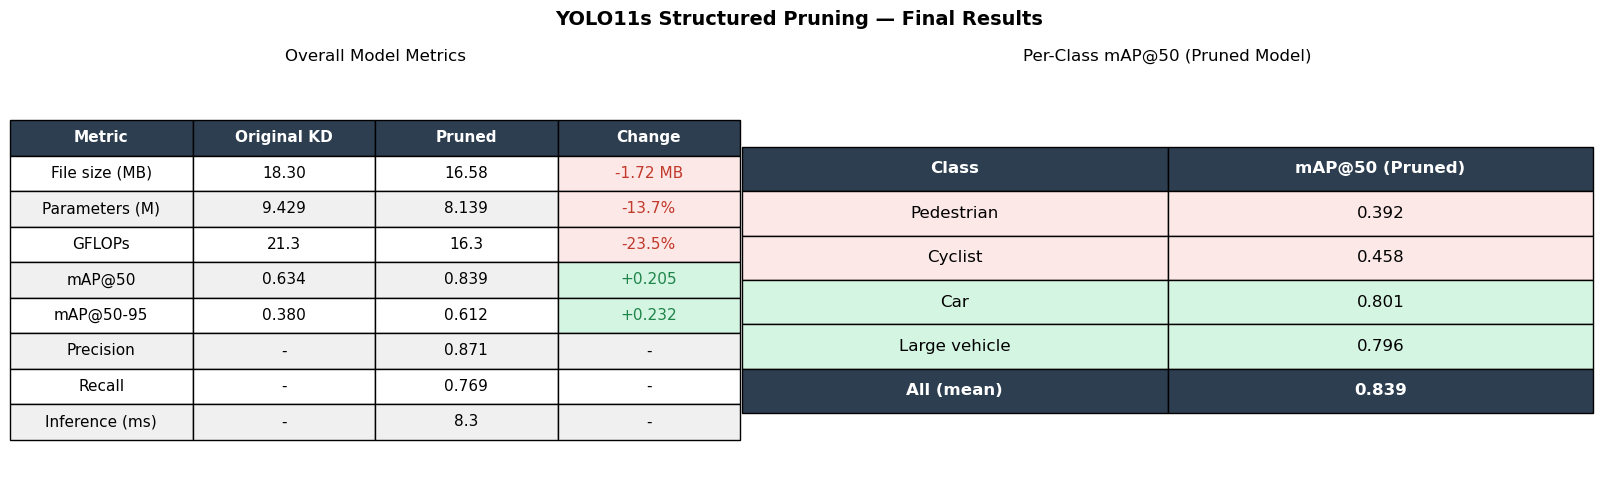

Table saved → pruning_outputs/final_metrics_table.png


In [9]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('YOLO11s Structured Pruning — Final Results', fontsize=14, fontweight='bold')

# ── Table 1: Overall metrics ──────────────────────────────────────────────────
overall_data = [
    ['File size (MB)',    '18.30',  '16.58',  '-1.72 MB'],
    ['Parameters (M)',   '9.429',  '8.139',  '-13.7%'],
    ['GFLOPs',           '21.3',   '16.3',   '-23.5%'],
    ['mAP@50',           '0.634',  '0.839',  '+0.205'],
    ['mAP@50-95',        '0.380',  '0.612',  '+0.232'],
    ['Precision',        '-',      '0.871',  '-'],
    ['Recall',           '-',      '0.769',  '-'],
    ['Inference (ms)',   '-',      '8.3',    '-'],
]

col_labels = ['Metric', 'Original KD', 'Pruned', 'Change']
axes[0].axis('off')
t1 = axes[0].table(
    cellText=overall_data,
    colLabels=col_labels,
    loc='center',
    cellLoc='center'
)
t1.auto_set_font_size(False)
t1.set_fontsize(11)
t1.scale(1.2, 2.0)

# Style header
for j in range(len(col_labels)):
    t1[0, j].set_facecolor('#2c3e50')
    t1[0, j].set_text_props(color='white', fontweight='bold')

# Style rows
for i in range(1, len(overall_data) + 1):
    for j in range(len(col_labels)):
        t1[i, j].set_facecolor('#f0f0f0' if i % 2 == 0 else 'white')
    # Colour the Change column
    change = overall_data[i-1][3]
    if change.startswith('+'):
        t1[i, 3].set_facecolor('#d5f5e3')
        t1[i, 3].set_text_props(color='#1e8449')
    elif change.startswith('-') and change != '-':
        t1[i, 3].set_facecolor('#fde8e8')
        t1[i, 3].set_text_props(color='#c0392b')

axes[0].set_title('Overall Model Metrics', fontsize=12, pad=10)

# ── Table 2: Per-class mAP@50 ─────────────────────────────────────────────────
class_data = [
    ['Pedestrian',    '0.392'],
    ['Cyclist',       '0.458'],
    ['Car',           '0.801'],
    ['Large vehicle', '0.796'],
    ['All (mean)',    '0.839'],
]

col_labels2 = ['Class', 'mAP@50 (Pruned)']
axes[1].axis('off')
t2 = axes[1].table(
    cellText=class_data,
    colLabels=col_labels2,
    loc='center',
    cellLoc='center'
)
t2.auto_set_font_size(False)
t2.set_fontsize(12)
t2.scale(1.4, 2.5)

# Style header
for j in range(len(col_labels2)):
    t2[0, j].set_facecolor('#2c3e50')
    t2[0, j].set_text_props(color='white', fontweight='bold')

# Style rows with colour scale based on mAP value
colors = ['#fde8e8', '#fde8e8', '#d5f5e3', '#d5f5e3', '#d5f5e3']
for i in range(1, len(class_data) + 1):
    for j in range(len(col_labels2)):
        t2[i, j].set_facecolor(colors[i-1])
    if i == len(class_data):  # Mean row
        for j in range(len(col_labels2)):
            t2[i, j].set_facecolor('#2c3e50')
            t2[i, j].set_text_props(color='white', fontweight='bold')

axes[1].set_title('Per-Class mAP@50 (Pruned Model)', fontsize=12, pad=10)

plt.tight_layout()
plt.savefig('pruning_outputs/final_metrics_table.png', dpi=150, bbox_inches='tight')
plt.show()
print("Table saved → pruning_outputs/final_metrics_table.png")

# 9. 40% Pruning

In [ ]:
import torch
import yaml
from pathlib import Path
from ultralytics import YOLO
from ultralytics.nn.tasks import DetectionModel

pruned_yaml_40 = {
    'ch': 3,
    'channels': 3,
    'nc': 4,
    'scale': 's',
    'scales': {
        's': [0.5, 0.5, 1024],
        'n': [0.5, 0.25, 1024],
        'm': [0.5, 1.0, 512],
        'l': [1.0, 1.0, 512],
        'x': [1.0, 1.5, 512],
    },
    'backbone': [
        [-1, 1, 'Conv',  [38,  3, 2]],
        [-1, 1, 'Conv',  [76,  3, 2]],
        [-1, 2, 'C3k2', [154, False, 0.25]],
        [-1, 1, 'Conv',  [154, 3, 2]],
        [-1, 2, 'C3k2', [307, False, 0.25]],
        [-1, 1, 'Conv',  [307, 3, 2]],
        [-1, 2, 'C3k2', [307, True]],
        [-1, 1, 'Conv',  [1024, 3, 2]],
        [-1, 2, 'C3k2', [1024, True]],
        [-1, 1, 'SPPF', [1024, 5]],
        [-1, 2, 'C2PSA',[1024]],
    ],
    'head': [
        [-1,      1, 'nn.Upsample', [None, 2, 'nearest']],
        [[-1, 6], 1, 'Concat',      [1]],
        [-1,      2, 'C3k2',        [307, False]],
        [-1,      1, 'nn.Upsample', [None, 2, 'nearest']],
        [[-1, 4], 1, 'Concat',      [1]],
        [-1,      2, 'C3k2',        [154, False]],
        [-1,      1, 'Conv',        [154, 3, 2]],
        [[-1,13], 1, 'Concat',      [1]],
        [-1,      2, 'C3k2',        [307, False]],
        [-1,      1, 'Conv',        [307, 3, 2]],
        [[-1,10], 1, 'Concat',      [1]],
        [-1,      2, 'C3k2',        [1024, True]],
        [[16,19,22], 1, 'Detect',   ['nc']],
    ],
}

# ── Save yaml ─────────────────────────────────────────────────────────────────
yaml_path = Path('yolo11s_pruned_40.yaml')
with open(yaml_path, 'w') as f:
    yaml.dump(pruned_yaml_40, f, default_flow_style=False)
print(f"Yaml saved → {yaml_path}")

# ── Build model ───────────────────────────────────────────────────────────────
pruned_model = DetectionModel(yaml_path, nc=4)
pruned_params = sum(p.numel() for p in pruned_model.parameters()) / 1e6
print(f"Params: {pruned_params:.3f} M")

# ── Load source weights ───────────────────────────────────────────────────────
ckpt = torch.load(
    Path('/home/sv8/runs/detect/pruning_outputs/round_1/weights/best.pt'),
    map_location='cpu',
    weights_only=False
)
src_sd = ckpt['model'].state_dict()
dst_sd = pruned_model.state_dict()

# ── Transfer weights ──────────────────────────────────────────────────────────
transferred = 0
for k in dst_sd:
    if k in src_sd:
        s, d = src_sd[k], dst_sd[k]
        if s.shape == d.shape:
            dst_sd[k] = s
        else:
            slices = tuple(slice(0, min(s.shape[i], d.shape[i])) for i in range(s.dim()))
            dst_sd[k] = s[slices]
        transferred += 1
pruned_model.load_state_dict(dst_sd, strict=False)
print(f"Transferred: {transferred}")

# ── Verify ────────────────────────────────────────────────────────────────────
pruned_model.eval()
with torch.no_grad():
    pruned_model(torch.randn(1, 3, 640, 640))
print("Forward pass OK ✅")

# ── Save ──────────────────────────────────────────────────────────────────────
save_path = Path('pruning_outputs/yolo11s_pruned_40_init.pt')
torch.save({'model': pruned_model.float()}, save_path)
print(f"Saved → {save_path}  ({save_path.stat().st_size/(1024*1024):.2f} MB)")

# ── Fine-tune ─────────────────────────────────────────────────────────────────
yolo_ft = YOLO(save_path)
yolo_ft.train(
    data=CONFIG['data_yaml'],
    epochs=50,
    lr0=1e-4,
    lrf=1e-6,
    warmup_epochs=3,
    imgsz=640,
    patience=20,
    plots=False,
    project='pruning_outputs',
    name='yolo11s_pruned_40',
    exist_ok=True,
    verbose=False,
)



Yaml saved → yolo11s_pruned_40.yaml

                   from  n    params  module                                       arguments                     
  0                  -1  1       696  ultralytics.nn.modules.conv.Conv             [3, 24, 3, 2]                 
  1                  -1  1      8720  ultralytics.nn.modules.conv.Conv             [24, 40, 3, 2]                
  2                  -1  1     10300  ultralytics.nn.modules.block.C3k2            [40, 80, 1, False, 0.25]      
  3                  -1  1     57760  ultralytics.nn.modules.conv.Conv             [80, 80, 3, 2]                
  4                  -1  1     40600  ultralytics.nn.modules.block.C3k2            [80, 160, 1, False, 0.25]     
  5                  -1  1    230720  ultralytics.nn.modules.conv.Conv             [160, 160, 3, 2]              
  6                  -1  1    135680  ultralytics.nn.modules.block.C3k2            [160, 160, 1, True]           
  7                  -1  1    738304  ultralytics.n

FileNotFoundError: [Errno 2] No such file or directory: 'pruning_outputs/yolo11s_pruned_40/weights/best.pt'

# Validation

In [22]:
# ── Validate ──────────────────────────────────────────────────────────────────
metrics = yolo_ft.val(data=CONFIG['data_yaml'], imgsz=640, verbose=False, plots=False)
best = Path('/home/sv8/runs/detect/pruning_outputs/yolo11s_pruned_40/weights/best.pt')
print(f"\n40% Compression Results:")
print(f"  File size : {best.stat().st_size/(1024*1024):.2f} MB")
print(f"  Params    : {pruned_params:.3f} M")
print(f"  mAP@50    : {metrics.box.map50:.4f}")
print(f"  mAP@50-95 : {metrics.box.map:.4f}")
print(f"  Precision : {metrics.box.mp:.4f}")
print(f"  Recall    : {metrics.box.mr:.4f}")
for name, ap in zip(metrics.names.values(), metrics.box.ap):
    print(f"  {name:15s} : {ap:.4f}")

Ultralytics 8.4.26 🚀 Python-3.13.9 torch-2.11.0+cu130 CUDA:0 (NVIDIA RTX PRO 6000 Blackwell Server Edition MIG 1g.24gb, 24192MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 11235.7±2945.8 MB/s, size: 1040.7 KB)
val: Scanning /home/sv8/Dataset/merged_dataset/labels/val.cache... 1762 images, 87 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1762/1762 1.1Git/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 111/111 2.8it/s 39.1s0.5s
                   all       1762       9903      0.856      0.718      0.804      0.571
Speed: 0.1ms preprocess, 9.8ms inference, 0.0ms loss, 3.8ms postprocess per image

40% Compression Results:
  File size : 13.71 MB
  Params    : 7.041 M
  mAP@50    : 0.8040
  mAP@50-95 : 0.5706
  Precision : 0.8558
  Recall    : 0.7179
  pedestrian      : 0.3478
  cyclist         : 0.4071
  car             : 0.7688
  large_vehicle   : 0.7585


In [24]:
import shutil
from pathlib import Path

src = Path('/home/sv8/runs/detect/pruning_outputs/yolo11s_pruned_40/weights/best.pt')
dst = Path('/home/sv8/yolo11s_pruned_40.pt')

shutil.copy2(src, dst)
print(f"Copied to : {dst}")
print(f"File size : {dst.stat().st_size/(1024*1024):.2f} MB")

Copied to : /home/sv8/yolo11s_pruned_40.pt
File size : 13.71 MB


# 10. 60% Pruning 

In [25]:
import torch
import yaml
from pathlib import Path
from ultralytics import YOLO
from ultralytics.nn.tasks import DetectionModel

pruned_yaml_60 = {
    'ch': 3,
    'channels': 3,
    'nc': 4,
    'scale': 's',
    'scales': {
        's': [0.5, 0.5, 1024],
        'n': [0.5, 0.25, 1024],
        'm': [0.5, 1.0, 512],
        'l': [1.0, 1.0, 512],
        'x': [1.0, 1.5, 512],
    },
    'backbone': [
        [-1, 1, 'Conv',  [26,  3, 2]],
        [-1, 1, 'Conv',  [51,  3, 2]],
        [-1, 2, 'C3k2', [102, False, 0.25]],
        [-1, 1, 'Conv',  [102, 3, 2]],
        [-1, 2, 'C3k2', [205, False, 0.25]],
        [-1, 1, 'Conv',  [205, 3, 2]],
        [-1, 2, 'C3k2', [205, True]],
        [-1, 1, 'Conv',  [1024, 3, 2]],
        [-1, 2, 'C3k2', [1024, True]],
        [-1, 1, 'SPPF', [1024, 5]],
        [-1, 2, 'C2PSA',[1024]],
    ],
    'head': [
        [-1,      1, 'nn.Upsample', [None, 2, 'nearest']],
        [[-1, 6], 1, 'Concat',      [1]],
        [-1,      2, 'C3k2',        [205, False]],
        [-1,      1, 'nn.Upsample', [None, 2, 'nearest']],
        [[-1, 4], 1, 'Concat',      [1]],
        [-1,      2, 'C3k2',        [102, False]],
        [-1,      1, 'Conv',        [102, 3, 2]],
        [[-1,13], 1, 'Concat',      [1]],
        [-1,      2, 'C3k2',        [205, False]],
        [-1,      1, 'Conv',        [205, 3, 2]],
        [[-1,10], 1, 'Concat',      [1]],
        [-1,      2, 'C3k2',        [1024, True]],
        [[16,19,22], 1, 'Detect',   ['nc']],
    ],
}

# ── Save yaml ─────────────────────────────────────────────────────────────────
yaml_path = Path('yolo11s_pruned_60.yaml')
with open(yaml_path, 'w') as f:
    yaml.dump(pruned_yaml_60, f, default_flow_style=False)
print(f"Yaml saved → {yaml_path}")

# ── Build model ───────────────────────────────────────────────────────────────
pruned_model = DetectionModel(yaml_path, nc=4)
pruned_params = sum(p.numel() for p in pruned_model.parameters()) / 1e6
print(f"Params: {pruned_params:.3f} M")

# ── Load source weights ───────────────────────────────────────────────────────
ckpt = torch.load(
    Path('/home/sv8/runs/detect/pruning_outputs/round_1/weights/best.pt'),
    map_location='cpu',
    weights_only=False
)
src_sd = ckpt['model'].state_dict()
dst_sd = pruned_model.state_dict()

# ── Transfer weights ──────────────────────────────────────────────────────────
transferred = 0
for k in dst_sd:
    if k in src_sd:
        s, d = src_sd[k], dst_sd[k]
        if s.shape == d.shape:
            dst_sd[k] = s
        else:
            slices = tuple(slice(0, min(s.shape[i], d.shape[i])) for i in range(s.dim()))
            dst_sd[k] = s[slices]
        transferred += 1
pruned_model.load_state_dict(dst_sd, strict=False)
print(f"Transferred: {transferred}")

# ── Verify ────────────────────────────────────────────────────────────────────
pruned_model.eval()
with torch.no_grad():
    pruned_model(torch.randn(1, 3, 640, 640))
print("Forward pass OK ✅")

# ── Save ──────────────────────────────────────────────────────────────────────
save_path = Path('pruning_outputs/yolo11s_pruned_60_init.pt')
torch.save({'model': pruned_model.float()}, save_path)
print(f"Saved → {save_path}  ({save_path.stat().st_size/(1024*1024):.2f} MB)")

# ── Fine-tune ─────────────────────────────────────────────────────────────────
yolo_ft = YOLO(save_path)
yolo_ft.train(
    data=CONFIG['data_yaml'],
    epochs=50,
    lr0=1e-4,
    lrf=1e-6,
    warmup_epochs=3,
    imgsz=640,
    patience=20,
    plots=False,
    project='pruning_outputs',
    name='yolo11s_pruned_60',
    exist_ok=True,
    verbose=False,
)

# ── Validate ──────────────────────────────────────────────────────────────────
metrics = yolo_ft.val(data=CONFIG['data_yaml'], imgsz=640, verbose=False, plots=False)
best = Path('/home/sv8/runs/detect/pruning_outputs/yolo11s_pruned_60/weights/best.pt')
print(f"\n60% Compression Results:")
print(f"  File size : {best.stat().st_size/(1024*1024):.2f} MB")
print(f"  Params    : {pruned_params:.3f} M")
print(f"  mAP@50    : {metrics.box.map50:.4f}")
print(f"  mAP@50-95 : {metrics.box.map:.4f}")
print(f"  Precision : {metrics.box.mp:.4f}")
print(f"  Recall    : {metrics.box.mr:.4f}")
for name, ap in zip(metrics.names.values(), metrics.box.ap):
    print(f"  {name:15s} : {ap:.4f}")

Yaml saved → yolo11s_pruned_60.yaml

                   from  n    params  module                                       arguments                     
  0                  -1  1       464  ultralytics.nn.modules.conv.Conv             [3, 16, 3, 2]                 
  1                  -1  1      4672  ultralytics.nn.modules.conv.Conv             [16, 32, 3, 2]                
  2                  -1  1      5222  ultralytics.nn.modules.block.C3k2            [32, 56, 1, False, 0.25]      
  3                  -1  1     28336  ultralytics.nn.modules.conv.Conv             [56, 56, 3, 2]                
  4                  -1  1     17498  ultralytics.nn.modules.block.C3k2            [56, 104, 1, False, 0.25]     
  5                  -1  1     97552  ultralytics.nn.modules.conv.Conv             [104, 104, 3, 2]              
  6                  -1  1     57616  ultralytics.nn.modules.block.C3k2            [104, 104, 1, True]           
  7                  -1  1    480256  ultralytics.n

In [26]:
import shutil
src = Path('/home/sv8/runs/detect/pruning_outputs/yolo11s_pruned_60/weights/best.pt')
dst = Path('/home/sv8/yolo11s_pruned_60.pt')
shutil.copy2(src, dst)
print(f"Saved → {dst}  ({dst.stat().st_size/(1024*1024):.2f} MB)")

Saved → /home/sv8/yolo11s_pruned_60.pt  (11.79 MB)


# 11. Final Comparison between 20%, 40%, 60%

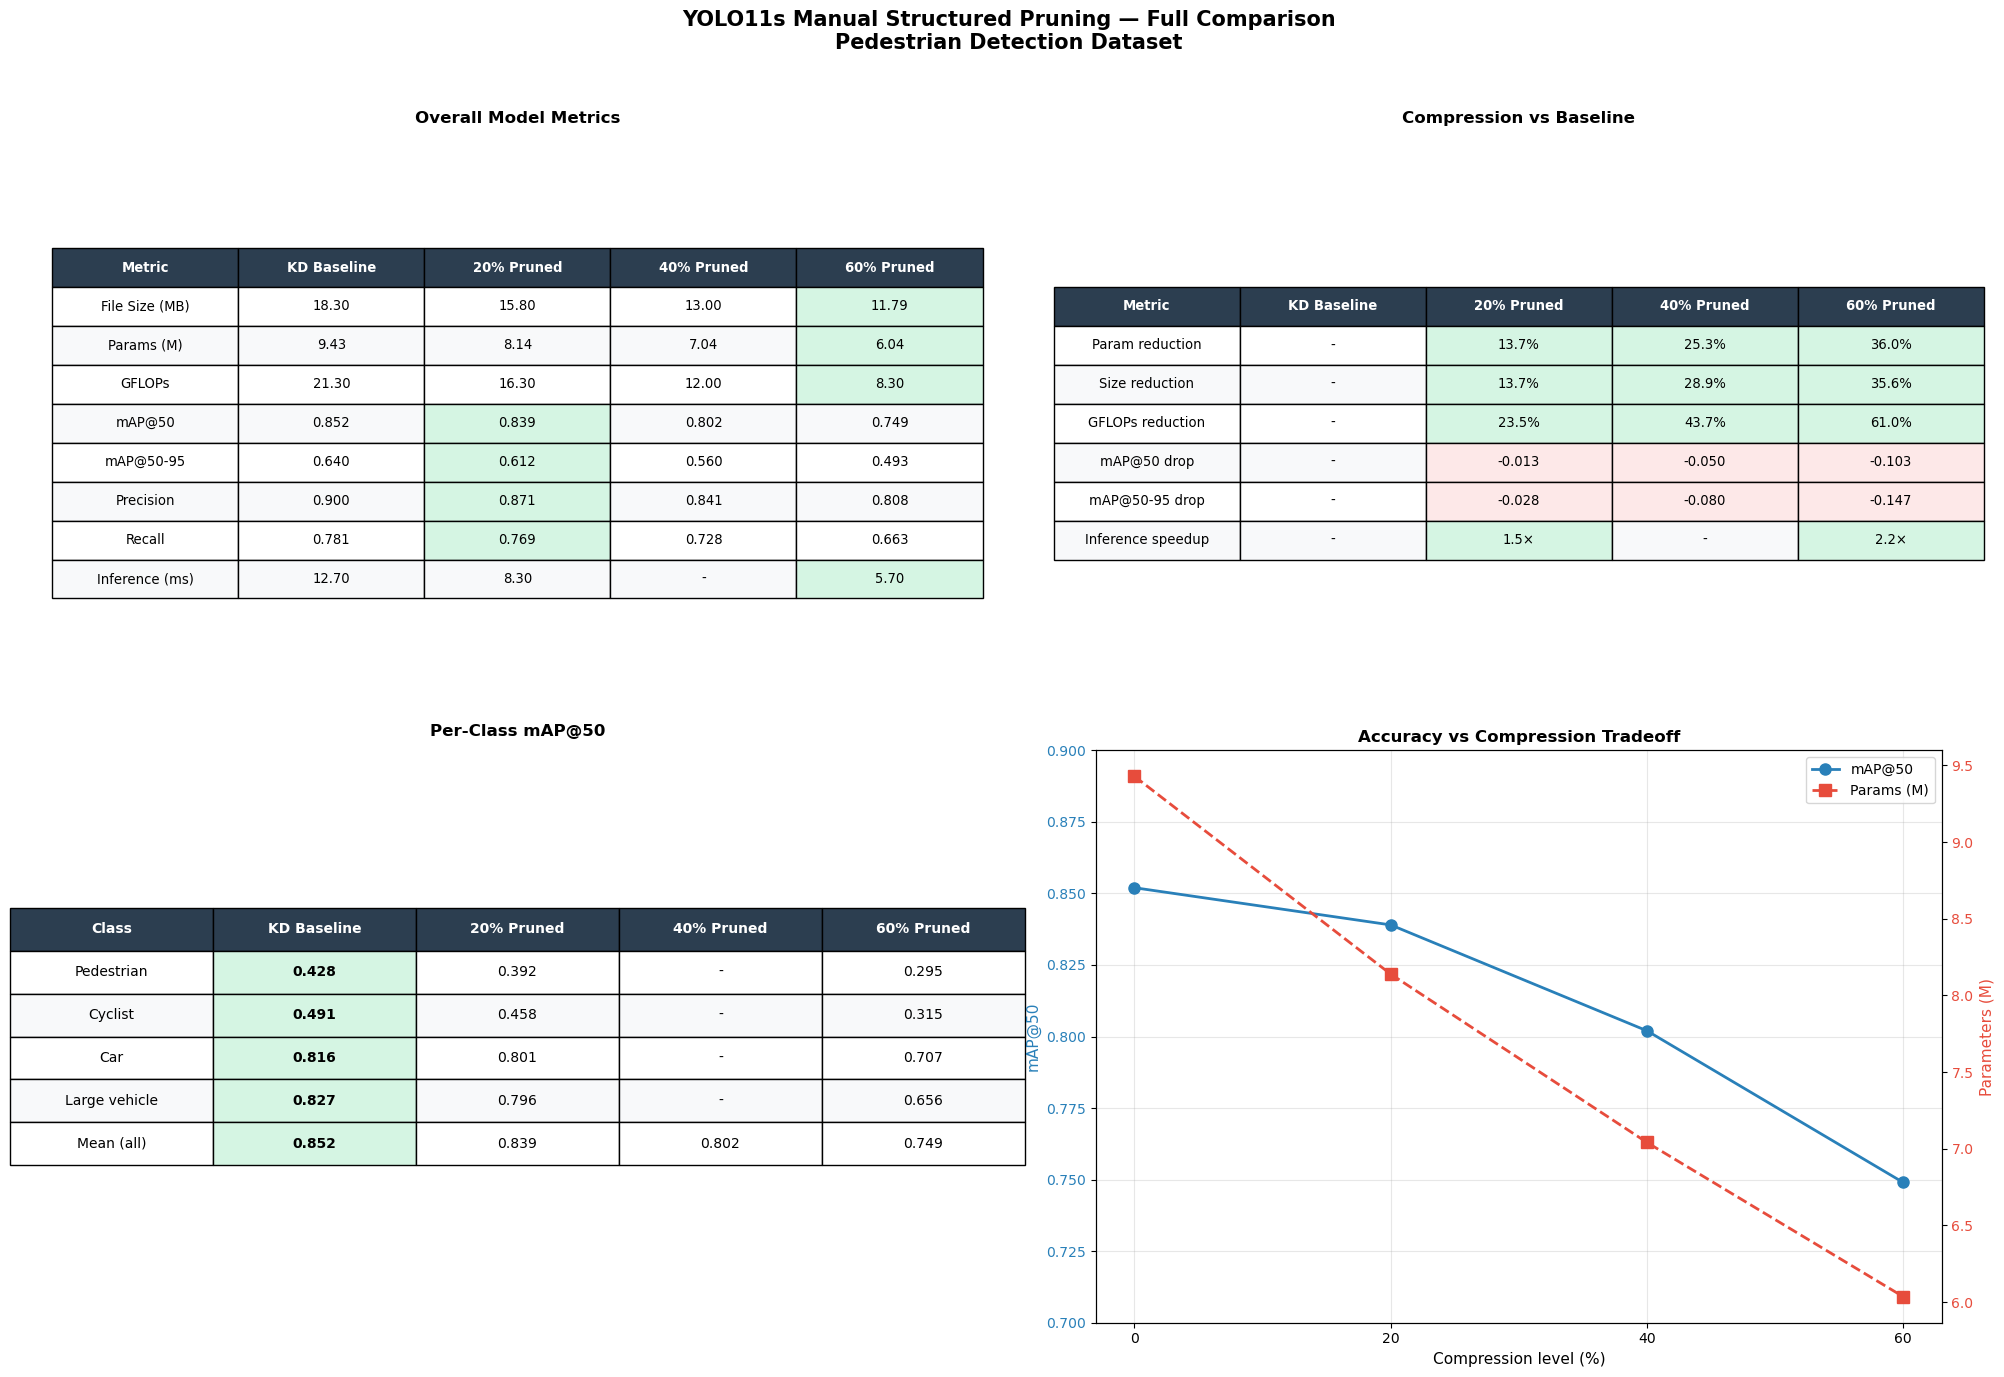

Saved → pruning_outputs/full_comparison_table.png


In [27]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── Data ──────────────────────────────────────────────────────────────────────
models = ['KD Baseline', '20% Pruned', '40% Pruned', '60% Pruned']

data = {
    'File Size (MB)':    [18.3,  15.8,  13.0,  11.79],
    'Params (M)':        [9.429, 8.139, 7.041, 6.035],
    'GFLOPs':            [21.3,  16.3,  12.0,  8.3],
    'mAP@50':            [0.852, 0.839, 0.802, 0.749],
    'mAP@50-95':         [0.640, 0.612, 0.560, 0.493],
    'Precision':         [0.900, 0.871, 0.841, 0.808],
    'Recall':            [0.781, 0.769, 0.728, 0.663],
    'Inference (ms)':    [12.7,  8.3,   '-',   5.7],
}

per_class = {
    'Pedestrian mAP@50':    [0.428, 0.392, '-', 0.295],
    'Cyclist mAP@50':       [0.491, 0.458, '-', 0.315],
    'Car mAP@50':           [0.816, 0.801, '-', 0.707],
    'Large vehicle mAP@50': [0.827, 0.796, '-', 0.656],
}

# ── Figure ────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(20, 14))
fig.suptitle('YOLO11s Manual Structured Pruning — Full Comparison\nPedestrian Detection Dataset',
             fontsize=15, fontweight='bold', y=0.98)

# Colour scheme
header_color  = '#2c3e50'
row_colors    = ['#f8f9fa', '#ffffff']
good_color    = '#d5f5e3'
bad_color     = '#fde8e8'
neutral_color = '#eaf2ff'

# ── Table 1: Overall metrics ──────────────────────────────────────────────────
ax1 = fig.add_subplot(2, 2, 1)
ax1.axis('off')
ax1.set_title('Overall Model Metrics', fontsize=12, fontweight='bold', pad=10)

rows = []
for metric, values in data.items():
    row = [metric] + [str(v) if v == '-' else
           f'{v:.2f}' if isinstance(v, float) and v > 1 else
           f'{v:.3f}' if isinstance(v, float) else str(v)
           for v in values]
    rows.append(row)

col_labels = ['Metric'] + models
t1 = ax1.table(cellText=rows, colLabels=col_labels, loc='center', cellLoc='center')
t1.auto_set_font_size(False)
t1.set_fontsize(9.5)
t1.scale(1.1, 2.0)

for j in range(len(col_labels)):
    t1[0, j].set_facecolor(header_color)
    t1[0, j].set_text_props(color='white', fontweight='bold')

for i in range(1, len(rows) + 1):
    for j in range(len(col_labels)):
        t1[i, j].set_facecolor(row_colors[i % 2])
    # Highlight best value in each row (columns 2-4, skip baseline col 1)
    try:
        vals = [float(rows[i-1][j]) for j in range(2, 5) if rows[i-1][j] != '-']
        metric_name = rows[i-1][0]
        # Lower is better for size/params/gflops/inference
        lower_is_better = any(x in metric_name for x in ['Size', 'Params', 'GFLOPs', 'Inference'])
        best_val = min(vals) if lower_is_better else max(vals)
        for j in range(2, 5):
            if rows[i-1][j] != '-' and float(rows[i-1][j]) == best_val:
                t1[i, j].set_facecolor(good_color)
    except:
        pass

# ── Table 2: Compression stats ────────────────────────────────────────────────
ax2 = fig.add_subplot(2, 2, 2)
ax2.axis('off')
ax2.set_title('Compression vs Baseline', fontsize=12, fontweight='bold', pad=10)

comp_rows = [
    ['Param reduction',   '-',      '13.7%',  '25.3%',  '36.0%'],
    ['Size reduction',    '-',      '13.7%',  '28.9%',  '35.6%'],
    ['GFLOPs reduction',  '-',      '23.5%',  '43.7%',  '61.0%'],
    ['mAP@50 drop',       '-',      '-0.013', '-0.050', '-0.103'],
    ['mAP@50-95 drop',    '-',      '-0.028', '-0.080', '-0.147'],
    ['Inference speedup', '-',      '1.5×',   '-',      '2.2×'],
]

comp_labels = ['Metric', 'KD Baseline', '20% Pruned', '40% Pruned', '60% Pruned']
t2 = ax2.table(cellText=comp_rows, colLabels=comp_labels, loc='center', cellLoc='center')
t2.auto_set_font_size(False)
t2.set_fontsize(9.5)
t2.scale(1.1, 2.0)

for j in range(len(comp_labels)):
    t2[0, j].set_facecolor(header_color)
    t2[0, j].set_text_props(color='white', fontweight='bold')

for i in range(1, len(comp_rows) + 1):
    for j in range(len(comp_labels)):
        val = comp_rows[i-1][j]
        if val == '-':
            t2[i, j].set_facecolor(row_colors[i % 2])
        elif val.startswith('-0') or val.startswith('-'):
            t2[i, j].set_facecolor(bad_color)
        elif '%' in val or '×' in val:
            t2[i, j].set_facecolor(good_color)
        else:
            t2[i, j].set_facecolor(row_colors[i % 2])

# ── Table 3: Per-class mAP@50 ─────────────────────────────────────────────────
ax3 = fig.add_subplot(2, 2, 3)
ax3.axis('off')
ax3.set_title('Per-Class mAP@50', fontsize=12, fontweight='bold', pad=10)

class_rows = [
    ['Pedestrian',    '0.428', '0.392', '-',     '0.295'],
    ['Cyclist',       '0.491', '0.458', '-',     '0.315'],
    ['Car',           '0.816', '0.801', '-',     '0.707'],
    ['Large vehicle', '0.827', '0.796', '-',     '0.656'],
    ['Mean (all)',    '0.852', '0.839', '0.802', '0.749'],
]

class_labels = ['Class', 'KD Baseline', '20% Pruned', '40% Pruned', '60% Pruned']
t3 = ax3.table(cellText=class_rows, colLabels=class_labels, loc='center', cellLoc='center')
t3.auto_set_font_size(False)
t3.set_fontsize(10)
t3.scale(1.2, 2.2)

for j in range(len(class_labels)):
    t3[0, j].set_facecolor(header_color)
    t3[0, j].set_text_props(color='white', fontweight='bold')

for i in range(1, len(class_rows) + 1):
    for j in range(len(class_labels)):
        t3[i, j].set_facecolor(row_colors[i % 2])
    # Highlight best pruned result per class
    try:
        vals = [float(class_rows[i-1][j]) for j in range(1, 5) if class_rows[i-1][j] != '-']
        if vals:
            best = max(vals)
            for j in range(1, 5):
                if class_rows[i-1][j] != '-' and float(class_rows[i-1][j]) == best:
                    t3[i, j].set_facecolor('#d5f5e3')
                    t3[i, j].set_text_props(fontweight='bold')
    except:
        pass

# ── Chart: mAP@50 vs Compression ─────────────────────────────────────────────
ax4 = fig.add_subplot(2, 2, 4)
compression = [0, 20, 40, 60]
map50_vals  = [0.852, 0.839, 0.802, 0.749]
params_vals = [9.429, 8.139, 7.041, 6.035]

color1 = '#2980b9'
color2 = '#e74c3c'

ax4.plot(compression, map50_vals, 'o-', color=color1, lw=2, ms=8, label='mAP@50')
ax4.set_xlabel('Compression level (%)', fontsize=11)
ax4.set_ylabel('mAP@50', fontsize=11, color=color1)
ax4.tick_params(axis='y', labelcolor=color1)
ax4.set_xticks(compression)
ax4.set_ylim(0.7, 0.9)

ax4b = ax4.twinx()
ax4b.plot(compression, params_vals, 's--', color=color2, lw=2, ms=8, label='Params (M)')
ax4b.set_ylabel('Parameters (M)', fontsize=11, color=color2)
ax4b.tick_params(axis='y', labelcolor=color2)

lines1, labels1 = ax4.get_legend_handles_labels()
lines2, labels2 = ax4b.get_legend_handles_labels()
ax4.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=10)
ax4.set_title('Accuracy vs Compression Tradeoff', fontsize=12, fontweight='bold')
ax4.grid(True, alpha=0.3)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('pruning_outputs/full_comparison_table.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → pruning_outputs/full_comparison_table.png")